# Dropout and Early Stopping in house price prediction using ANN and LSTM and comparison between both

### Data Collection And Preprocessing

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\lenovo\Desktop\HousePrice.csv")

# Drop unnecessary columns
df = df.drop(['date','street','city','statezip','country'], axis=1)

# Handle missing values
df = df.dropna()

# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

### PRACTICAL 1: ANN with Dropout + Early Stopping

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input



In [13]:
# Build ANN Model
model = Sequential()

# ✅ Correct Input Layer
model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

In [14]:
# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [15]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [16]:
# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 448260866048.0000 - mae: 546825.0000 - val_loss: 401324867584.0000 - val_mae: 536658.3125
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 446776934400.0000 - mae: 545743.5000 - val_loss: 397436157952.0000 - val_mae: 533633.9375
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 434763005952.0000 - mae: 537079.5000 - val_loss: 376110678016.0000 - val_mae: 517072.1250
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 391498891264.0000 - mae: 505208.0312 - val_loss: 315773976576.0000 - val_mae: 467175.0000
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 298084040704.0000 - mae: 430275.3125 - val_loss: 216110219264.0000 - val_mae: 368158.0312
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 185611501568.0000 - mae: 317211.0000 - val_loss: 129620197376.0000 - val_mae: 259212.3906
Epoch 7/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 121610723328.0000 - mae: 237333.8281 - val_loss

In [17]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 981771419648.0000 - mae: 204160.8281 
Test MAE: 204160.828125


### PRACTICAL 2: LSTM with Dropout + Early Stopping

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
# Reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [22]:
# Build LSTM Model
model_lstm = Sequential()

# ✅ Input Layer FIRST
model_lstm.add(Input(shape=(1, X_train.shape[1])))

model_lstm.add(LSTM(64, activation='relu'))
model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dense(1))

In [23]:
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [24]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [25]:
# Train
history_lstm = model_lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 448301858816.0000 - mae: 546856.1250 - val_loss: 401509679104.0000 - val_mae: 536808.8750
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 448279379968.0000 - mae: 546840.5000 - val_loss: 401461739520.0000 - val_mae: 536770.4375
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 448158564352.0000 - mae: 546752.2500 - val_loss: 401274994688.0000 - val_mae: 536618.8125
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 447806767104.0000 - mae: 546502.0000 - val_loss: 400828792832.0000 - val_mae: 536259.5000
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 447127158784.0000 - mae: 546011.6250 - val_loss: 400030695424.0000 - val_mae: 535621.5000
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 446019502080.0000 - mae: 545209.3750 - val_loss: 398838923264.0000 - val_mae: 534658.7500
Epoch 7/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 444414361600.0000 - mae: 544041.1875 - val_loss

In [26]:
# Evaluate
loss, mae = model_lstm.evaluate(X_test_lstm, y_test)
print("Test MAE (LSTM):", mae)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 989554540544.0000 - mae: 211650.4375 
Test MAE (LSTM): 211650.4375


### Graphical Representation for ANN model: 

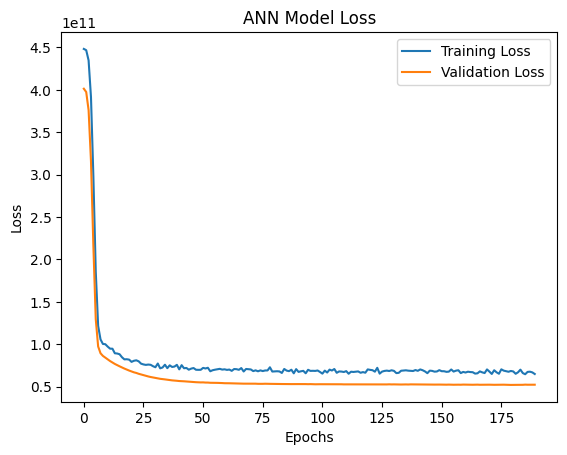

In [27]:
import matplotlib.pyplot as plt

# ANN Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ANN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

### Graphical Representation for LSTM model: 

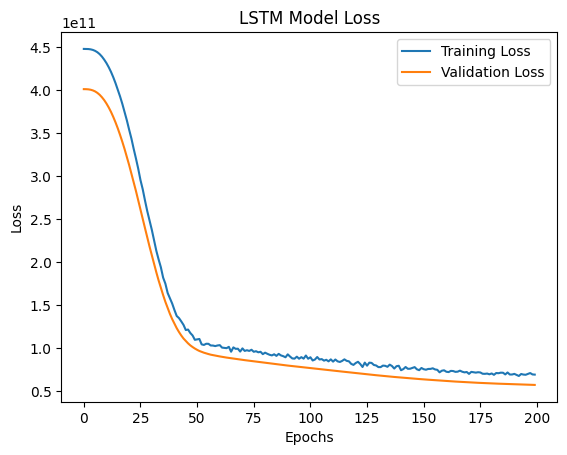

In [28]:
# LSTM Graph
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

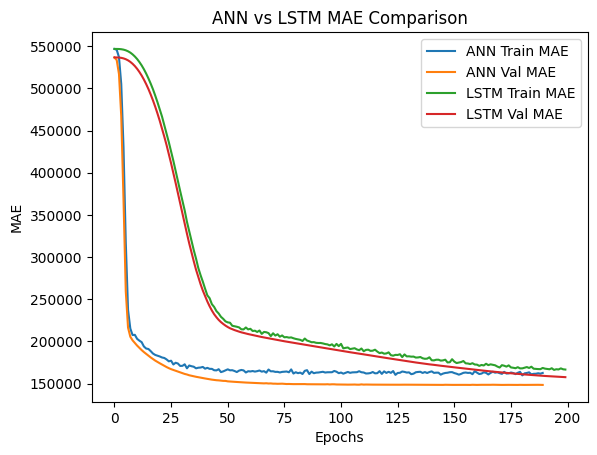

In [29]:
# MAE Graph Comparison
plt.figure()

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.plot(history_lstm.history['mae'])
plt.plot(history_lstm.history['val_mae'])

plt.title('ANN vs LSTM MAE Comparison')
plt.xlabel('Epochs')
plt.ylabel('MAE')

plt.legend([
    'ANN Train MAE',
    'ANN Val MAE',
    'LSTM Train MAE',
    'LSTM Val MAE'
])

plt.show()

In [30]:
print("ANN Final MAE:", history.history['val_mae'][-1])
print("LSTM Final MAE:", history_lstm.history['val_mae'][-1])

ANN Final MAE: 148320.234375
LSTM Final MAE: 157528.875
